DAta downloading

Pulling data from kaagle

In [2]:
import kagglehub

path=kagglehub.dataset_download("abdallahaboelkhair/heartbeat-sound")

print("Path to Dataset Files",path)


100%|██████████| 110M/110M [02:19<00:00, 828kB/s]  

Extracting files...


Path to Dataset Files C:\Users\zahee\.cache\kagglehub\datasets\abdallahaboelkhair\heartbeat-sound\versions\1


# **Heartbeat sounds**

Heart sounds are produced from a
specific cardiac event such as closure of
a valve or tensing of a chordae
tendineae.

• S1 result from the closing of the mitral
and tricuspid valves.

• S2 produced by the closure of the aortic
and pulmonic valves.

# About data:

Is challenge published in 2012 to classify the heart sound to some categories from ‘AISTATS’ .
Data has been gathered from two sources (A) and (B).

A) from the general public via the iStethoscope Pro.

B) from a clinic trial in hospitals using the digital stethoscope DigiScope.

Before we work on this nootebook we handle the data folders and conctante both sources(A&B) to be easy to deal with it.

Original Data here: http://www.peterjbentley.com/heartchallenge/

# Import main libraries

In [23]:
import os
import glob
import fnmatch
import pandas as pd
import numpy as np
import librosa
import seaborn as sns
import matplotlib.pyplot as plt
import IPython.display as ipd
import math
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import concatenate
from tensorflow.keras.models import Sequential,Model,load_model
from tensorflow.keras.layers import Conv1D,Conv2D,SeparableConv1D,MaxPool1D,MaxPool2D
from tensorflow.keras.layers import Input,add,Flatten,Dense,BatchNormalization,Dropout,LSTM,GRU
from tensorflow.keras import regularizers
from tensorflow.keras import backend as k 
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef
from sklearn.metrics import cohen_kappa_score,roc_auc_score,confusion_matrix,classification_report

loading

In [10]:
data_path='../Heartbeat_Sound'
print(os.listdir(data_path))

['artifact', 'extrahls', 'extrastole', 'murmur', 'normal', 'unlabel']


In [15]:
train_data=data_path
unlabel_data=train_data+"/unlabel/"
normal_data=train_data+'/normal/'
murmur_data=train_data+'/murmur/'
extrastole_data=train_data+'/extrastole'
artifacts_data=train_data+'/artifact'
extrahls_data=train_data+'/extrahls'

In [22]:
print("Normal Files:",len(os.listdir(normal_data)))
print("Murmur files:",len(os.listdir(murmur_data)))
print("Extrastole files:",len(os.listdir(extrastole_data)))
print("Artifacts files:",len(os.listdir(artifacts_data)))
print("Extrahls files:",len(os.listdir(extrahls_data)))
print("TOTAL TRAIN SOUNDS:",len(os.listdir(normal_data))
                            +len(os.listdir(murmur_data))
                            +len(os.listdir(extrastole_data))
                            +len(os.listdir(artifacts_data))
                            +len(os.listdir(extrahls_data)))


Normal Files: 351
Murmur files: 129
Extrastole files: 46
Artifacts files: 40
Extrahls files: 19
TOTAL TRAIN SOUNDS: 585


# EDA and Visualization

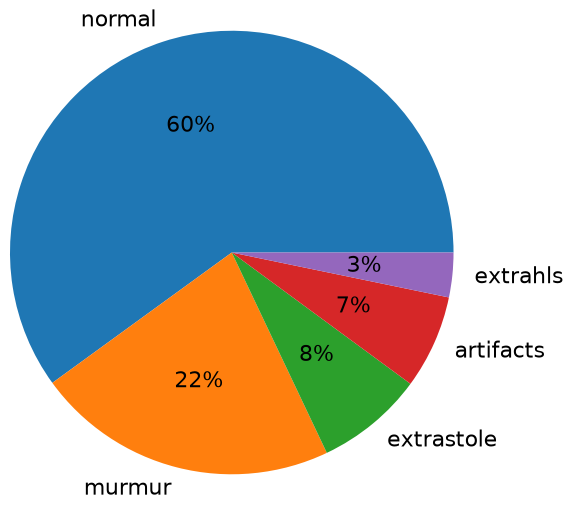

In [27]:
x=np.array([len(os.listdir(normal_data))
                            ,len(os.listdir(murmur_data))
                            ,len(os.listdir(extrastole_data))
                            ,len(os.listdir(artifacts_data))
                            ,len(os.listdir(extrahls_data))])
labels=['normal','murmur','extrastole','artifacts','extrahls']
plt.pie(x,labels=labels,autopct='%.0f%%',radius=1.5,textprops={'fontsize':16})
plt.show()

##### The figure shows imbalanced data so we need to fix it later


### To pick a random sound

In [28]:
def random_sound(audio_class):
    random_sound=np.random.randint(0,len(os.listdir(audio_class)))
    sound=os.listdir(audio_class)[random_sound]
    sound=audio_class+sound
    sound,sample_rate=librosa.load(sound)
    return ipd.Audio(sound,rate=sample_rate),sound

### Waveform

Sound is the pressure of air propagates to our ear. Digital audio file is gotten from a sound sensor that can detects sound waves and converting it to electrical signals.
Specifically, it's telling us about the wave's displacement, and how it changes over time.



In [29]:
def show_audio_waveform(audio_sample):
    plt.figure(figsize=(20,5))
    librosa.display.waveshow(audio_sample,sr=22050)
    plt.title("Sound")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.show()

### Spectrum

A sound spectrum is a representation of a sound – usually a short sample of a sound – in terms of the amount of vibration at each individual frequency. It is usually presented as a graph of either power or pressure as a function of frequency. The power or pressure is usually measured in decibels and the frequency is measured in vibrations per second (or hertz, abbreviation Hz) or thousands of vibrations per second (kilohertz, abbreviation kHz).

The spectrum expresses the frequency composition of the sound and is obtained by analyzing the sound. A sound spectrum is usually represented in a coordinate plane where the frequency f is plotted along the axis of abscissas and the amplitude A, or intensity, of a harmonic component with a given frequency is plotted along the axis of ordinates.

In [30]:
def show_audio_spectrum(audio_Sample):
    sample_rate=22050
    fft_normal=np.fft.fft(audio_Sample)
    magnitude_normal=np.abs(fft_normal)
    freq_normal=np.linspace(0,sample_rate,len(magnitude_normal))
    half_freq=freq_normal[:int(len(freq_normal)/2)]
    half_magnitude=magnitude_normal[:int(len(freq_normal)/2)]

    plt.figure(figsize=(12,8))
    plt.plot(half_freq,half_magnitude)
    plt.title('Spectrum')
    plt.xlabel("Frequency")
    plt.ylabel("Magnitude")
    plt.show()


### Spectogram

For us, as human, we sense a sound not only on a particular time by its intensity, but also by its pitch. The pitch is the frequency of the sound - higher pitch corresponding to higher frequency and vice versa. So, to have a representation which is closer to our brain, we can add another dimension - the frequency - to our representation, which is the Spectrogram.

A spectrogram is a visual representation of the spectrum of frequencies of a signal as it varies with time. When applied to an audio signal, spectrograms are sometimes called sonographs, voiceprints, or voicegrams.

Spectrograms are used extensively in the fields of music, linguistics, sonar, radar, speech processing,seismology, and others. Spectrograms of audio can be used to identify spoken words phonetically, and to analyse the various calls of animals.it can be generated by an optical spectrometer, a bank of band-pass filters, by Fourier transform or by a wavelet transform.

In [ ]:
def show_spectrogram(audio_sample):
    hop_length=512
    n_fft=2048
    sample_rate=22050

    hop_lenght_duration=float(hop_length)/sample_rate
    n_fft_duration=float(n_fft)/sample_rate

    print("STFT hop length duration is : {}s".format(hop_lenght_duration))
    print("STFT window duration is: {}s".format(n_fft_duration))

    stft_normal=librosa.stft(audio_sample,n_fft=n_fft,hop_length=hop_length)

    spectrogram=np.abs(stft_normal)
    log_spectogram=librosa.amplitude_to_db(spectrogram)

    plt.figure(figsize=(15,10))
    librosa.display.specshow(log_spectogram,sr=sample_rate,hop_length=hop_length)
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.colorbar()
    plt.title("Spectrogram")

### MFCCs

We can’t take the raw audio signal as input to our model because there will be a lot of noise in the audio signal. It is observed that extracting features from the audio signal and using it as input to the base model will produce much better performance than directly considering raw audio signal as input. MFCC is the widely used technique for extracting the features from the audio signal.

in sound processing, the mel-frequency cepstrum (MFC) is a representation of the short-term power spectrum of a sound, based on a linear cosine transform of a log power spectrum on a nonlinear mel scale of frequency.

Mel-frequency cepstral coefficients (MFCCs) are coefficients that collectively make up an MFC. They are derived from a type of cepstral representation of the audio clip (a nonlinear "spectrum-of-a-spectrum"). The difference between the cepstrum and the mel-frequency cepstrum is that in the MFC, the frequency bands are equally spaced on the mel scale, which approximates the human auditory system's response more closely than the linearly-spaced frequency bands used in the normal spectrum. This frequency warping can allow for better representation of sound, for example, in audio compression.

**MFCCs are commonly derived as follows:**

1- Take the Fourier transform of (a windowed excerpt of) a signal.

2- Map the powers of the spectrum obtained above onto the mel scale, using triangular overlapping windows or alternatively, cosine overlapping windows.

3- Take the logs of the powers at each of the mel frequencies.

4- Take the discrete cosine transform of the list of mel log powers, as if it were a signal.

5- The MFCCs are the amplitudes of the resulting spectrum.

In [31]:
def show_mfcc_feature(audio_sample):
    hop_length=512
    n_fft=2048
    sample_rate=22050

    MFCCS=librosa.feature.mfcc(
        y=audio_sample,
        sr=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mfcc=52
    )

    plt.figure(figsize=(15,10))
    librosa.display.specshow(MFCCS,sr=sample_rate,hop_length=hop_length)
    plt.xlabel("Time")
    plt.ylabel("MFCC coefficients")
    plt.colorbar()
    plt.title("MFCCS")
    plt.show()